# E. Coli DNA signal exploration notebook

This notebook explores the **NCBI RefSeq _Escherichia coli_ K-12 MG1655 complete genome** (accession **NC_000913.3**) as a possible project topic for signal and wavelet analysis.
**Notes**: 
- NCBI: National Center for Biotechnology Information
- GenBank: NIH sequencing database
- CDS: Coding Sequences
- RefSeq: Reference Sequence; provides DNA, RNA, protein sequences, and annotations

Why E. Coli?
- small enough to work with comfortably on a laptop
   - E.Coli: 4.6 million base pairs
   - Humans: 3 billion base pairs
- complete genome
- high-quality RefSeq annotation
- easy to fetch directly from NCBI in GenBank format, which includes sequence + feature annotations

This notebook:
1. loads the data from NCBI
2. visualizes the DNA in native genomic form
3. converts the DNA into useful signal representations
4. visualizes those signals
5. computes a spectrogram from a DNA-derived signal

## Main signal choices used here

Two signal representations are used:

1. **GC indicator signal**
   - `1` for `G` or `C`
   - `0` for `A` or `T`
   - pros:
      - simple
      - interpretable
      - commonly used to analyze structure in genomics
   - cons:
      - loses fine detail (no distinction between G/C, or A/T)

2. **Four nucleotide indicator signals**
   - separate binary signals for `A`, `C`, `G`, `T`
   - preserves all nucleotide categories without imposing an artificial numeric ordering
   - pros:
      - captures all of the fine detail
   - cons:
      - noisier

A spectrogram is created from the **GC indicator signal**; this is a time-frequency style view of how local periodicity/variation changes along the sequence.


In [1]:
import io
import math
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import spectrogram
from Bio import Entrez, SeqIO
import Bio

plt.rcParams["figure.figsize"] = (12, 5)

ACCESSION = "NC_000913.3"  # E. coli K-12 MG1655 complete genome
EMAIL = "daniel_mcgonigle1@student.uml.edu"  # NCBI asks for an email

Entrez.email = EMAIL


## 1. Load sequence + annotations from NCBI

We fetch the genome in **GenBank** format so we get:
- the sequence _**for one strand**_
- metadata
- gene / CDS / RNA annotations


In [2]:
def fetch_genbank_record(accession: str) -> Bio.SeqRecord.SeqRecord:
    """
    Fetch a nucleotide sequence record from NCBI and parse it into a Biopython SeqRecord.

    This function retrieves a record from the NCBI Entrez "nuccore" database
    (the primary repository for nucleotide sequences, including genomic DNA,
    mRNA, and RefSeq genomes). The record is returned in GenBank format and
    parsed into a structured SeqRecord object.

    Parameters
    ----------
    accession : str
        NCBI accession identifier (e.g., "NC_000913.3" for the Escherichia coli
        K-12 MG1655 reference genome). RefSeq accessions with the "NC_" prefix
        correspond to curated reference genomes. The suffix (e.g., ".3")
        indicates the version of the record.

    Returns
    -------
    record : Bio.SeqRecord.SeqRecord
        A SeqRecord object containing:
        - `record.seq`: the nucleotide sequence
        - `record.features`: annotated genomic features (e.g., CDS regions)
        - metadata such as organism, references, and annotations

    Notes
    -----
    - db="nuccore":
        Specifies the NCBI nucleotide database. Other databases (e.g., "protein",
        "pubmed") are used for different types of data and are not appropriate
        for genomic DNA retrieval.

    - rettype="gbwithparts":
        Requests the GenBank flat-file format with complete feature annotations,
        including complex/joined feature locations. This is important for
        accurately extracting CDS regions.

    - retmode="text":
        Returns the record as plain-text GenBank format, which is required
        for parsing with Biopython's SeqIO.

    - SeqIO.read(..., "genbank"):
        Parses the GenBank-formatted text into a SeqRecord object. The
        "genbank" argument specifies the input format for the parser.
    """

    with Entrez.efetch(db="nuccore", id=accession, rettype="gbwithparts", retmode="text") as handle:
        text = handle.read()
    record = SeqIO.read(io.StringIO(text), "genbank")
    return record

record = fetch_genbank_record(ACCESSION)
sequence = str(record.seq).upper()
genome_len = len(sequence)

print(f"Record ID: {record.id}; type: {type(record)}")
print(f"Description: {record.description}")
print(f"Genome length: {genome_len:,} bp")
print(f"Number of annotated features: {len(record.features):,}")


Record ID: NC_000913.3; type: <class 'Bio.SeqRecord.SeqRecord'>
Description: Escherichia coli str. K-12 substr. MG1655, complete genome
Genome length: 4,641,652 bp
Number of annotated features: 9,285


## 2. Native-format DNA views

These first plots stay close to the original genomic representation.


In [3]:
# Base composition
base_counts = Counter([b for b in sequence if b in "ACGT"])
base_df = pd.DataFrame({
    "base": list("ACGT"),
    "count": [base_counts[b] for b in "ACGT"]
})
base_df["fraction"] = base_df["count"] / base_df["count"].sum()
base_df


,base,count,fraction
0,A,1142742,0.246193
1,C,1180091,0.254239
2,G,1177437,0.253668
3,T,1141382,0.245900


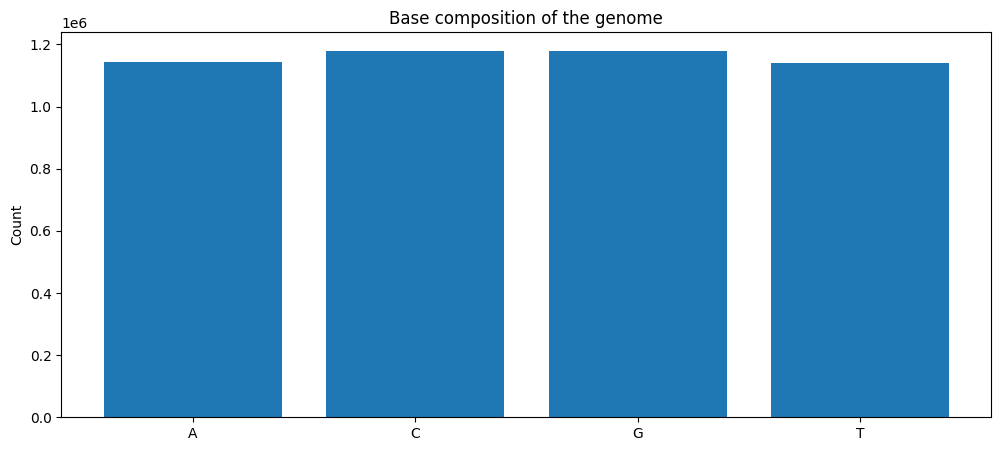

In [4]:
fig, ax = plt.subplots()
ax.bar(base_df["base"], base_df["count"])
ax.set_title("Base composition of the genome")
ax.set_ylabel("Count")
plt.show()


In [5]:
# Show a small native sequence window
window_start = 0
window_len = 300
snippet = sequence[window_start:window_start+window_len]

print(f"Sequence positions {window_start+1:,} to {window_start+window_len:,}:")
for i in range(0, len(snippet), 60):
    chunk = snippet[i:i+60]
    print(f"{window_start+i+1:>9,}: {chunk}")


Sequence positions 1 to 300:
        1: AGCTTTTCATTCTGACTGCAACGGGCAATATGTCTCTGTGTGGATTAAAAAAAGAGTGTC
       61: TGATAGCAGCTTCTGAACTGGTTACCTGCCGTGAGTAAATTAAAATTTTATTGACTTAGG
      121: TCACTAAATACTTTAACCAATATAGGCATAGCGCACAGACAGATAAAAATTACAGAGTAC
      181: ACAACATCCATGAAACGCATTAGCACCACCATTACCACCACCATCACCATTACCACAGGT
      241: AACGGTGCGGGCTGACGCGTACAGGAAACACAGAAAAAAGCCCGCACCTGACAGTGCGGG


In [6]:
# Show feature types available
feature_types = set(
    [
        feat.type for feat in record.features
    ]
)
print(feature_types)

{'misc_feature', 'ncRNA', 'rep_origin', 'source', 'mobile_element', 'gene', 'CDS', 'tRNA', 'rRNA'}


In [7]:
# Extract a compact annotation table for genes / CDS / RNAs
rows = []
for feat in record.features:
    if feat.type in {"gene", "CDS", "rRNA", "tRNA"}:
        start = int(feat.location.start)
        end = int(feat.location.end)
        strand = feat.location.strand
        qualifiers = feat.qualifiers
        rows.append({
            "type": feat.type,
            "start": start,
            "end": end,
            "length": end - start,
            "strand": strand,
            "gene": qualifiers.get("gene", [""])[0],
            "locus_tag": qualifiers.get("locus_tag", [""])[0],
            "product": qualifiers.get("product", [""])[0],
        })

feature_df = pd.DataFrame(rows).sort_values(["start", "end"]).reset_index(drop=True)
feature_df.head(15)


,type,start,end,length,strand,gene,locus_tag,product
0,gene,189,255,66,1,thrL,b0001,
1,CDS,189,255,66,1,thrL,b0001,thr operon leader peptide
2,gene,336,2799,2463,1,thrA,b0002,
3,CDS,336,2799,2463,1,thrA,b0002,fused aspartate kinase/homoserine dehydrogenase 1
4,gene,2800,3733,933,1,thrB,b0003,
5,CDS,2800,3733,933,1,thrB,b0003,homoserine kinase
6,gene,3733,5020,1287,1,thrC,b0004,
7,CDS,3733,5020,1287,1,thrC,b0004,threonine synthase
8,gene,5233,5530,297,1,yaaX,b0005,
9,CDS,5233,5530,297,1,yaaX,b0005,DUF2502 domain-containing protein YaaX


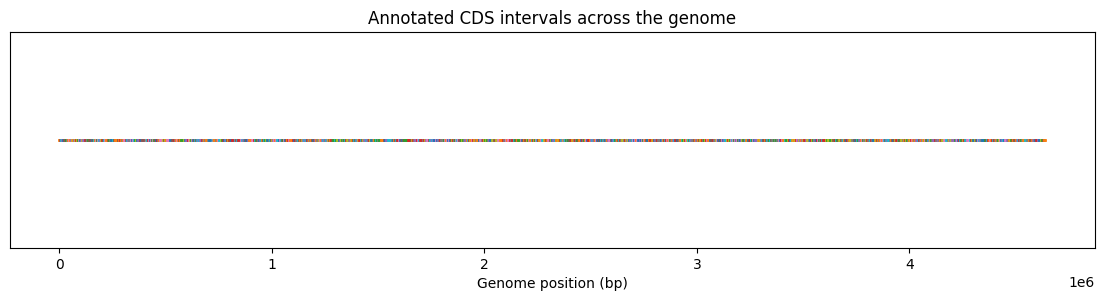

In [8]:
# Visualize where coding sequences (CDS) lie along the genome
cds_df = feature_df[feature_df["type"] == "CDS"].copy()

fig, ax = plt.subplots(figsize=(14, 2.8))
for _, row in cds_df.iterrows():
    ax.plot([row["start"], row["end"]], [1, 1], linewidth=2)

ax.set_title("Annotated CDS intervals across the genome")
ax.set_xlabel("Genome position (bp)")
ax.set_yticks([])
plt.show()


## 3. Convert DNA to signals

### Signal A: GC indicator
`1` if the base is `G` or `C`, else `0`

### Signal B: four binary indicator channels
- `A[n]`
- `C[n]`
- `G[n]`
- `T[n]`


In [16]:
# Main signal encodings
CDS_FEATURES = {"CDS"}
NONCDS_FEATURES = {feat.type for feat in record.features} - CDS_FEATURES

def create_binary_signal(bases: str, feature_types: set[str] | None = None) -> np.ndarray:
    """
    Create a binary indicator signal over the genome sequence.

    Parameters
    ----------
    bases : str
        One or more nucleotide letters to mark with 1s (for example, "GC" or "A").
    feature_types : set[str] | None, optional
        If provided, first extract only the bases that fall inside annotated
        features whose type is in this set (for example, CDS_FEATURES or
        NONCDS_FEATURES), then build the binary signal on that reduced sequence.

    Returns
    -------
    binary_signal : 1-D np.ndarray of 0's and 1's
    """
    selected_bases = {base.upper() for base in bases if not base.isspace()}
    if not selected_bases:
        raise ValueError("bases must contain at least one nucleotide letter")

    if feature_types is None:
        sequence_to_encode = sequence
    else:
        selected_segments = []
        for feat in record.features:
            if feat.type not in feature_types:
                continue

            parts = getattr(feat.location, "parts", [feat.location])
            for part in parts:
                start = int(part.start)
                end = int(part.end)
                selected_segments.append(sequence[start:end])

        sequence_to_encode = "".join(selected_segments)

    return np.fromiter((1 if base in selected_bases else 0 for base in sequence_to_encode), dtype=np.int8)

gc_signal = create_binary_signal("GC")

indicator_signals = {
    base: create_binary_signal(base)
    for base in "ACGT"
}

print("GC signal length:", len(gc_signal))
print("Indicator signal keys:", list(indicator_signals.keys()))
for indicator in list(indicator_signals.keys()):
    print(f"indicator {indicator} : {len(indicator_signals[indicator])}")

GC signal length: 4641652
Indicator signal keys: ['A', 'C', 'G', 'T']
indicator A : 4641652
indicator C : 4641652
indicator G : 4641652
indicator T : 4641652


In [17]:

gc_cds = create_binary_signal("GC", feature_types=CDS_FEATURES)

indicator_cds = {
    base: create_binary_signal(base, feature_types=CDS_FEATURES)
    for base in "ACGT"
}

print("GC signal length:", len(gc_cds))
print("Indicator signal keys:", list(indicator_cds.keys()))
for indicator in list(indicator_cds.keys()):
    print(f"indicator {indicator} : {len(indicator_cds[indicator])}")

GC signal length: 4026887
Indicator signal keys: ['A', 'C', 'G', 'T']
indicator A : 4026887
indicator C : 4026887
indicator G : 4026887
indicator T : 4026887


In [18]:

gc_noncds = create_binary_signal("GC", feature_types=NONCDS_FEATURES)

indicator_noncds = {
    base: create_binary_signal(base, feature_types=NONCDS_FEATURES)
    for base in "ACGT"
}

print("GC signal length:", len(gc_noncds))
print("Indicator signal keys:", list(indicator_noncds.keys()))
for indicator in list(indicator_noncds.keys()):
    print(f"indicator {indicator} : {len(indicator_noncds[indicator])}")

GC signal length: 9118190
Indicator signal keys: ['A', 'C', 'G', 'T']
indicator A : 9118190
indicator C : 9118190
indicator G : 9118190
indicator T : 9118190


In [11]:
# Quick sanity checks
print("Overall GC fraction:", gc_signal.mean())
for base in "ACGT":
    print(f"{base} fraction:", indicator_signals[base].mean())


Overall GC fraction: 0.5079070985933456
A fraction: 0.24619295026856816
C fraction: 0.2542394388894299
G fraction: 0.25366765970391575
T fraction: 0.2458999511380862


## 4. Signal visualizations

Because the genome is long, we use both:
- **local views** (small windows)
- **aggregated/rolling views** (to show larger trends)


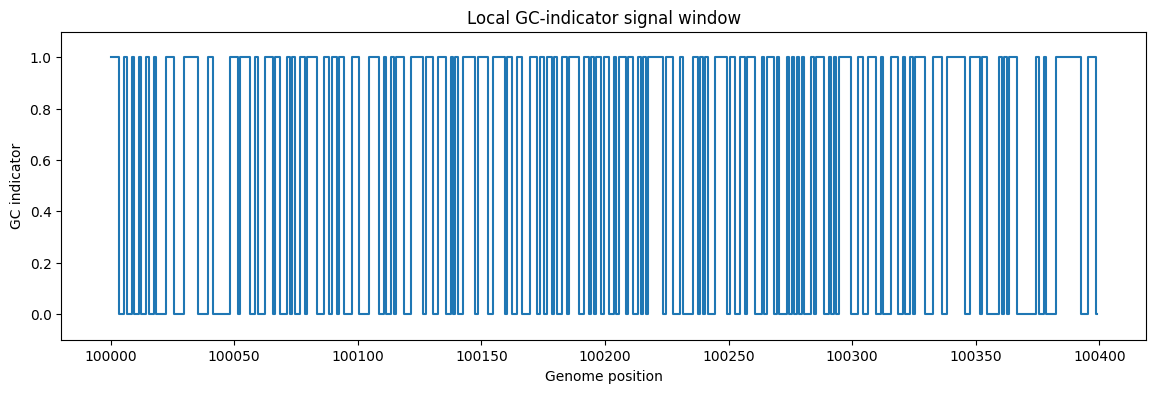

In [12]:
# Local window view of raw signals
local_start = 100_000
local_len = 400
local_end = local_start + local_len
x_local = np.arange(local_start, local_end)

fig, ax = plt.subplots(figsize=(14, 4))
ax.step(x_local, gc_signal[local_start:local_end], where="mid")
ax.set_title("Local GC-indicator signal window")
ax.set_xlabel("Genome position")
ax.set_ylabel("GC indicator")
ax.set_ylim(-0.1, 1.1)
plt.show()


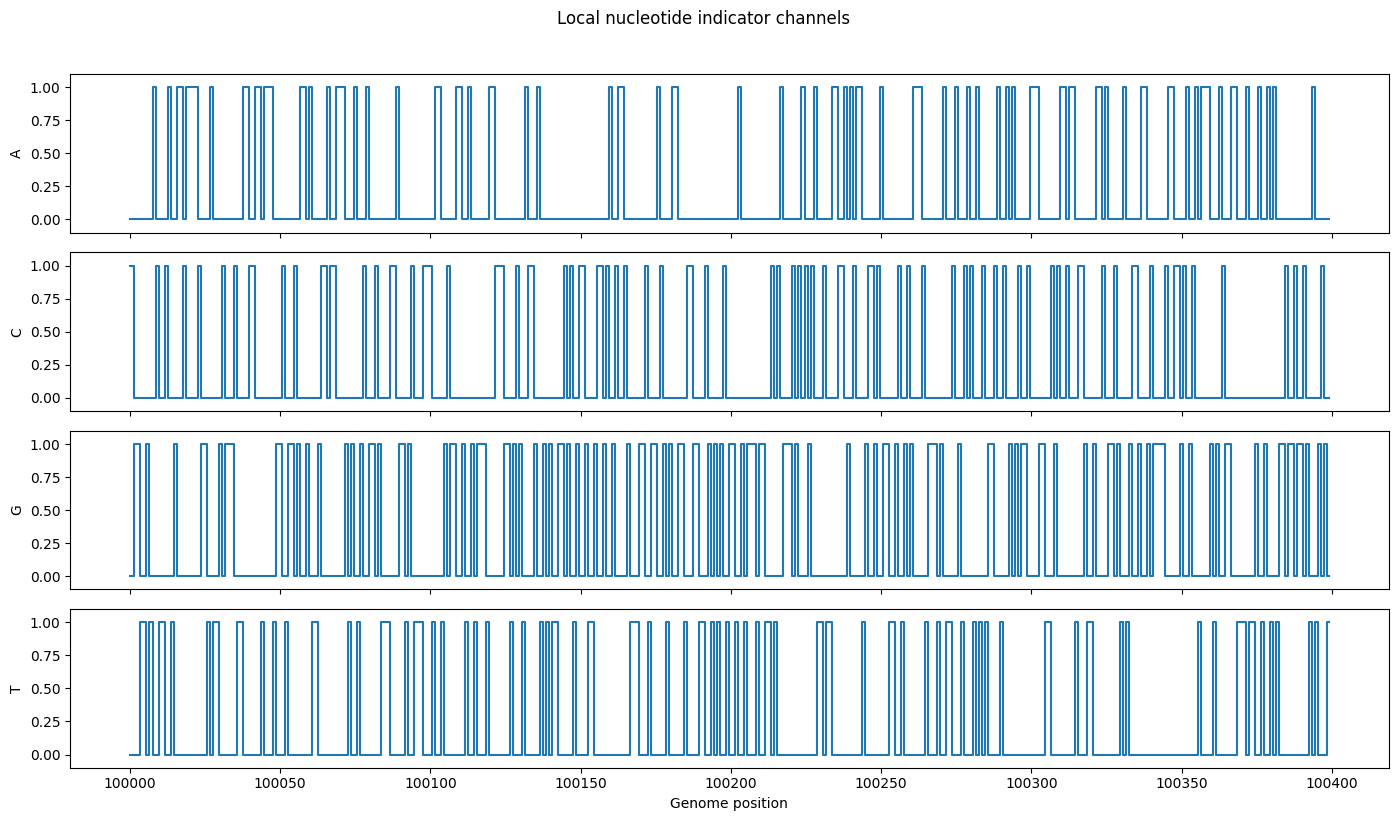

In [13]:
# Local view of A/C/G/T indicator channels
fig, axes = plt.subplots(4, 1, figsize=(14, 8), sharex=True)
for ax, base in zip(axes, "ACGT"):
    ax.step(x_local, indicator_signals[base][local_start:local_end], where="mid")
    ax.set_ylim(-0.1, 1.1)
    ax.set_ylabel(base)
axes[-1].set_xlabel("Genome position")
fig.suptitle("Local nucleotide indicator channels", y=1.02)
plt.tight_layout()
plt.show()


## 5. DNA FFT and spectrogram

Let's start with a FFT to visualize the frequency distribution across this dataset, then move to a spectrogram, which will capture a bit of the time- and frequency- characteristics.  Spectrograms compromise between the following problems (using a Gabor transformation):
- The time- or space-varying signal captures the instantaneous temporal intensities perfectly, but none of the frequency information
- The Fourier transformation of the signal captures the global frequency information, but loses all temporal information.

We build it from the **demeaned GC indicator signal**:
- treat genome position like the sample axis
- examine how local frequency content changes over position

This can sometimes reveal localized periodicity or changes in compositional texture.


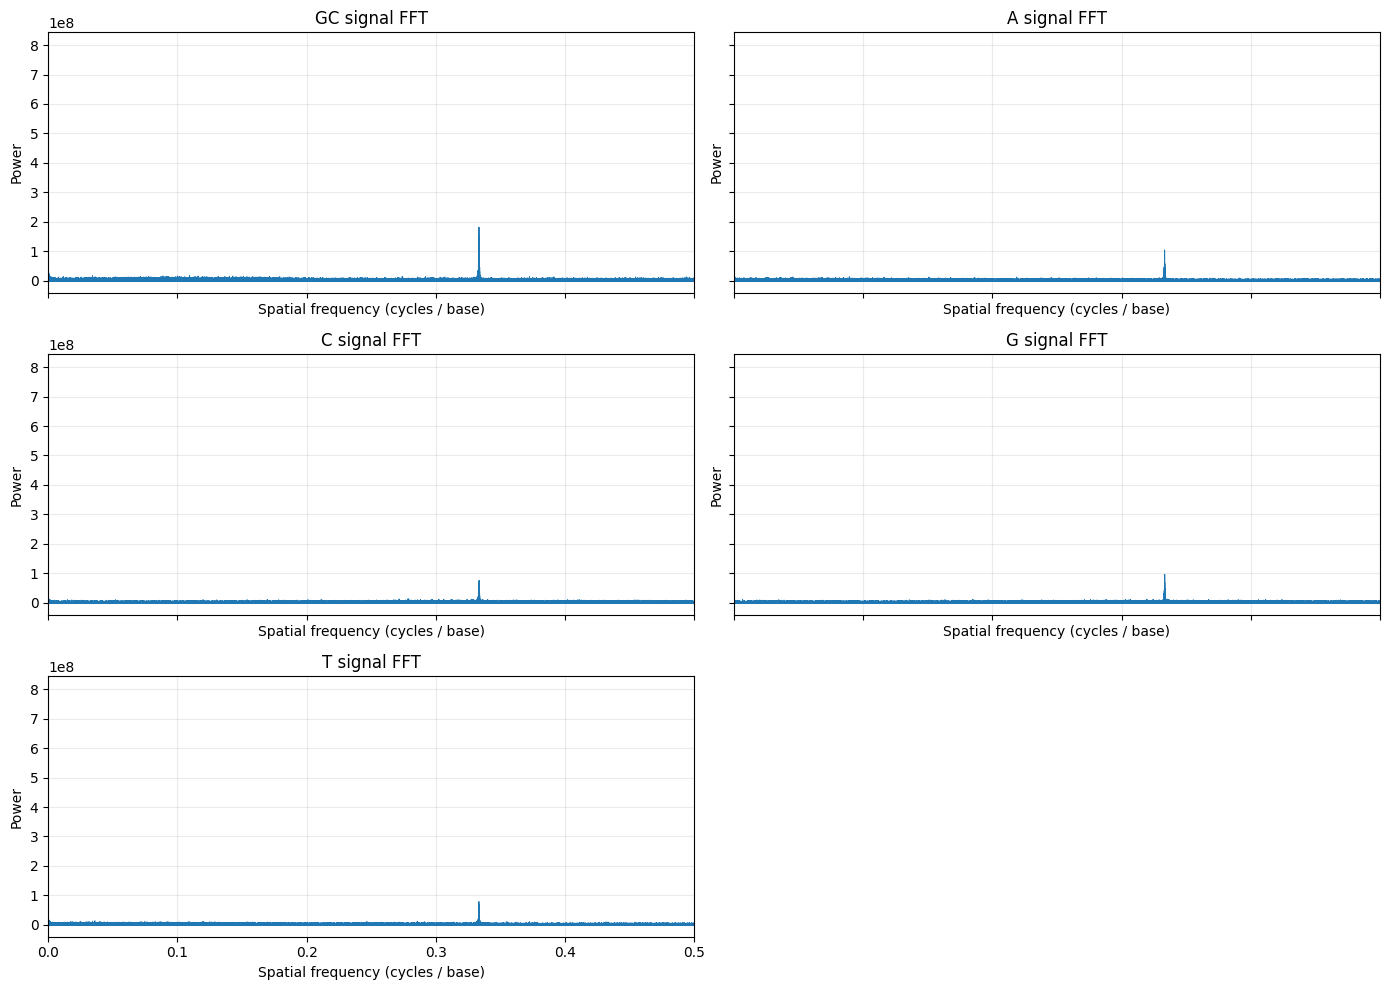

In [14]:
# Fourier magnitude of the GC signal and A/C/G/T indicator signals
import numpy as np
import matplotlib.pyplot as plt

signals = {"GC": gc_signal.astype(float)}
signals.update({base: indicator_signals[base].astype(float) for base in "ACGT"})

fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True, sharey=True)
axes = axes.ravel()

for ax, (name, x) in zip(axes, signals.items()):
    x = x - x.mean()
    fft_vals = np.fft.rfft(x)
    freqs = np.fft.rfftfreq(len(x), d=1.0)  # cycles per base
    power = np.abs(fft_vals) ** 2

    ax.plot(freqs[1:], power[1:], lw=0.7)
    ax.set_title(f"{name} signal FFT")
    ax.set_xlim(0, 0.5)
    ax.set_xlabel("Spatial frequency (cycles / base)")
    ax.set_ylabel("Power")
    ax.grid(alpha=0.25)

axes[-1].axis("off")
plt.tight_layout()
plt.show()

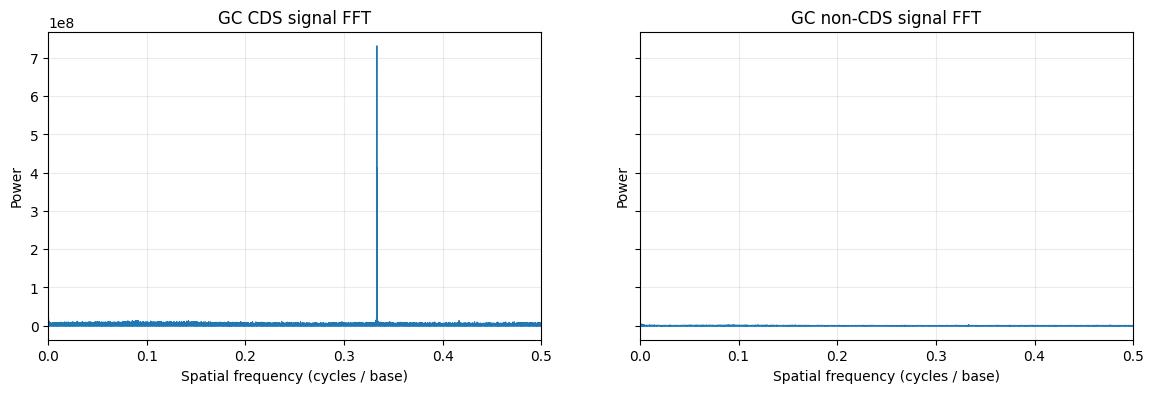

In [20]:
# Fourier magnitude of GC signals restricted to CDS and non-CDS regions

cds_mask = np.zeros(len(sequence), dtype=bool)
for feat in record.features:
    if feat.type != "CDS":
        continue

    parts = getattr(feat.location, "parts", [feat.location])
    for part in parts:
        start = int(part.start)
        end = int(part.end)
        cds_mask[start:end] = True

sequence_array = np.asarray(list(sequence))
gc_cds_fft_signal = np.fromiter(
    (1 if base in {"G", "C"} else 0 for base in sequence_array[cds_mask]),
    dtype=np.int8,
).astype(float)
gc_noncds_fft_signal = np.fromiter(
    (1 if base in {"G", "C"} else 0 for base in sequence_array[~cds_mask]),
    dtype=np.int8,
).astype(float)

fft_signals = {
    "GC CDS": gc_cds_fft_signal,
    "GC non-CDS": gc_noncds_fft_signal,
}

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True, sharey=True)

for ax, (name, x) in zip(axes, fft_signals.items()):
    x = x - x.mean()
    fft_vals = np.fft.rfft(x)
    freqs = np.fft.rfftfreq(len(x), d=1.0)
    power = np.abs(fft_vals) ** 2

    ax.plot(freqs[1:], power[1:], lw=0.7)
    ax.set_title(f"{name} signal FFT")
    ax.set_xlim(0, 0.5)
    ax.set_xlabel("Spatial frequency (cycles / base)")
    ax.set_ylabel("Power")
    ax.grid(alpha=0.25)

plt.show()


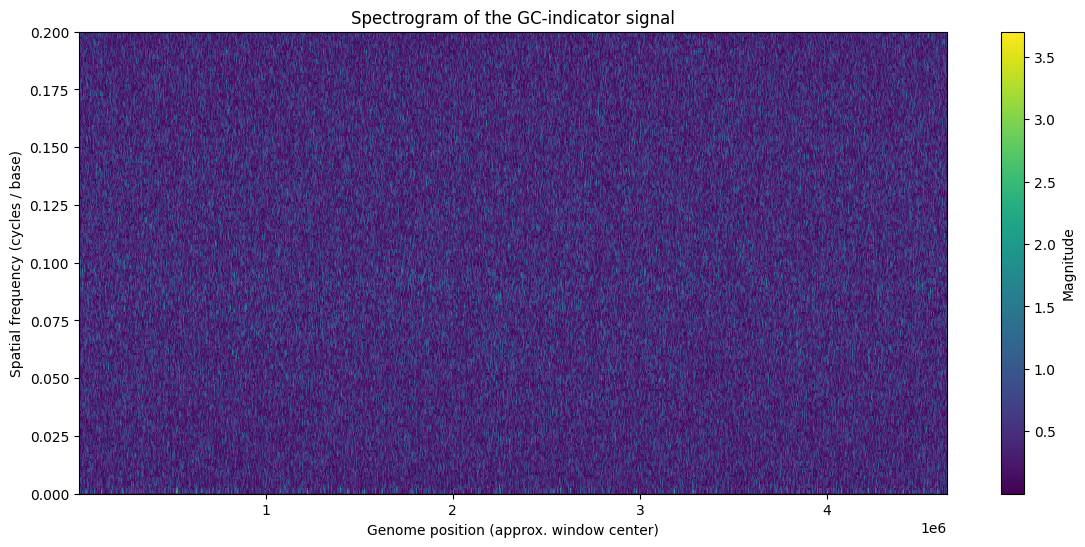

In [19]:
gc_centered = gc_signal.astype(float) - gc_signal.mean()

fs = 1.0  # 1 sample per base
f, t, Sxx = spectrogram(
    gc_centered,
    fs=fs,
    window="hann",
    nperseg=1024,
    noverlap=768,
    scaling="density",
    mode="magnitude",
)

fig, ax = plt.subplots(figsize=(14, 6))
pcm = ax.pcolormesh(t, f, Sxx, shading="auto")
ax.set_title("Spectrogram of the GC-indicator signal")
ax.set_xlabel("Genome position (approx. window center)")
ax.set_ylabel("Spatial frequency (cycles / base)")
ax.set_ylim(0, 0.2)  # focus on lower frequencies for readability
fig.colorbar(pcm, ax=ax, label="Magnitude")
plt.show()
